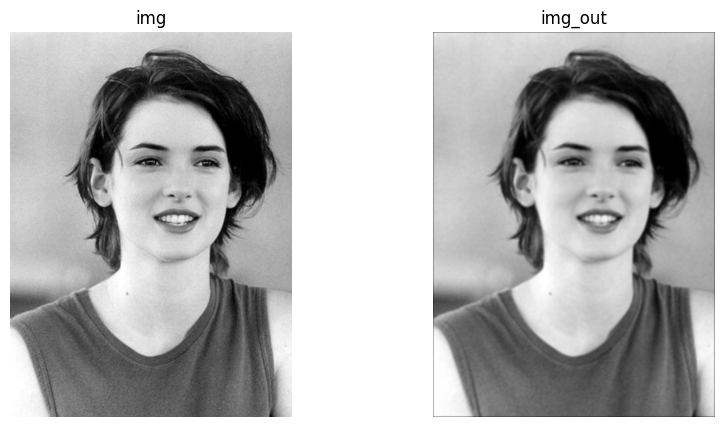

In [7]:
import tensorflow as tf
from tensorflow.keras.layers import MaxPooling2D, Conv2D
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Steps 2~9 (25 points)
# Enter your code here.
inputs = tf.keras.Input((None, None, 1))
kernel_size = 5
stride=1
outputs = Conv2D(1, kernel_size, stride, padding='same', name='conv1')(inputs)
filter_net = tf.keras.Model(inputs, outputs)
bias = np.array([0])
weights = np.ones((kernel_size, kernel_size, 1, 1)) / (kernel_size ** 2)
filter_net.get_layer('conv1').set_weights([weights, bias])
img = cv2.imread('Winona.jpg', cv2.IMREAD_GRAYSCALE)
img_batch = np.expand_dims(img, axis=0)
img_batch = np.expand_dims(img_batch, axis=-1)
img_out = filter_net(img_batch)
img_out = np.array(img_out, dtype=np.uint8).reshape(img.shape[0], img.shape[1])
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('img')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(img_out, cmap='gray')
plt.title('img_out')
plt.axis('off')
plt.show()
#[Question 1 (5 points)] If kernel_size in Steps 3 and 5 is changed from 5 to 11,
# how will img_out change (more blurry or more clear)? Why?
如果把kernel_size從5改成11，那img_out會變得更模糊，因為這個convolution的weight每個值都一樣，
當kernel從5x5變成11x11時，每個像素會和更大範圍內的周圍像素一起平均，細節會少更多，所以影像會更模糊。

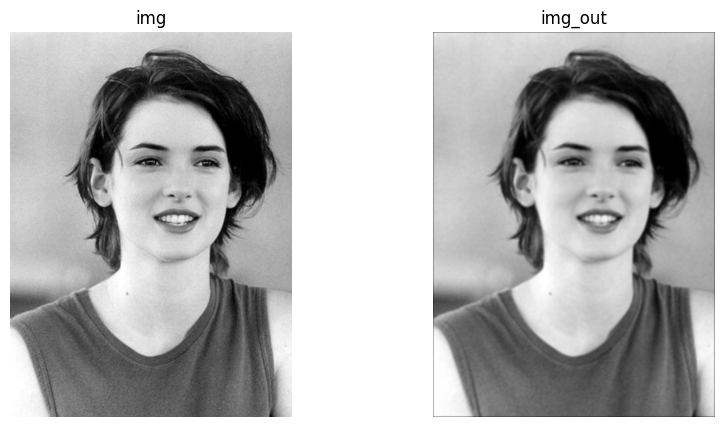

In [10]:
# Steps 10~13 (15 points)
# Enter your code here.
pad = int((kernel_size - 1) / 2)
img_pad = np.zeros((772 + 2 * pad, 564 + 2 * pad))
img_pad[pad:pad+772, pad:pad+564] = img
inputs = tf.keras.Input((None, None, 1))
padding = 'valid'
outputs = tf.keras.layers.Conv2D(1, kernel_size, stride, padding, name='conv1')(inputs)
filter_net = tf.keras.Model(inputs, outputs)
bias = np.array([0])
weights = np.ones((kernel_size, kernel_size, 1, 1)) / (kernel_size ** 2)
filter_net.get_layer('conv1').set_weights([weights, bias])
img_batch = np.expand_dims(img_pad, axis=0)
img_batch = np.expand_dims(img_batch, axis=-1)
img_out = filter_net(img_batch)
img_out = np.array(img_out, dtype=np.uint8).reshape(772, 564)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('img')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img_out, cmap='gray')
plt.title('img_out')
plt.axis('off')
plt.show()
# [Question 2 (5 points)] Let Step 2 to Step 9 be denoted as Method 1, and Step 10 to Step 13 be denoted as Method 2. 
# Why Methods 1 and 2 lead to the same results?
Method1是 TensorFlow 自動補0。
Method2是自己先補0，再做valid convolution。
因為兩種方法補0完全一樣，所以卷積時看到的輸入資料相同，最後輸出結果也相同